In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from multidim_visualization import HighDimVisualizer

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12,8]

In [3]:
visualizer = HighDimVisualizer(random_state=42)

Загрузка датасета online_shoppers_intention.csv

Первые строки датасета:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb       

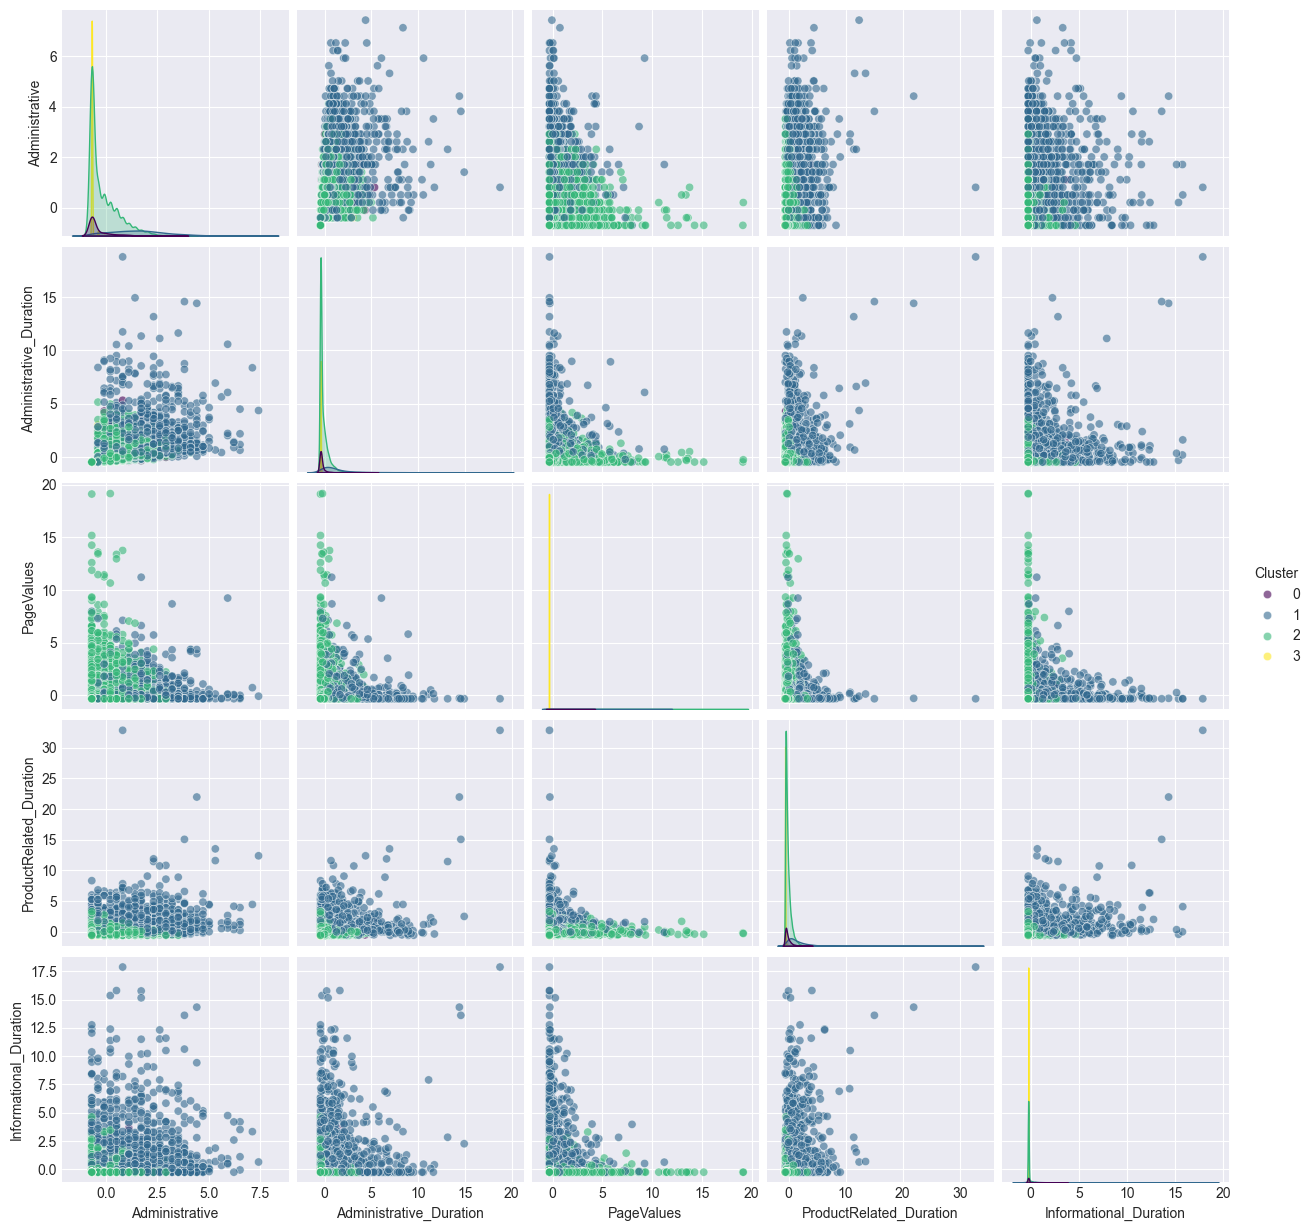


2. Корреляционная матрица


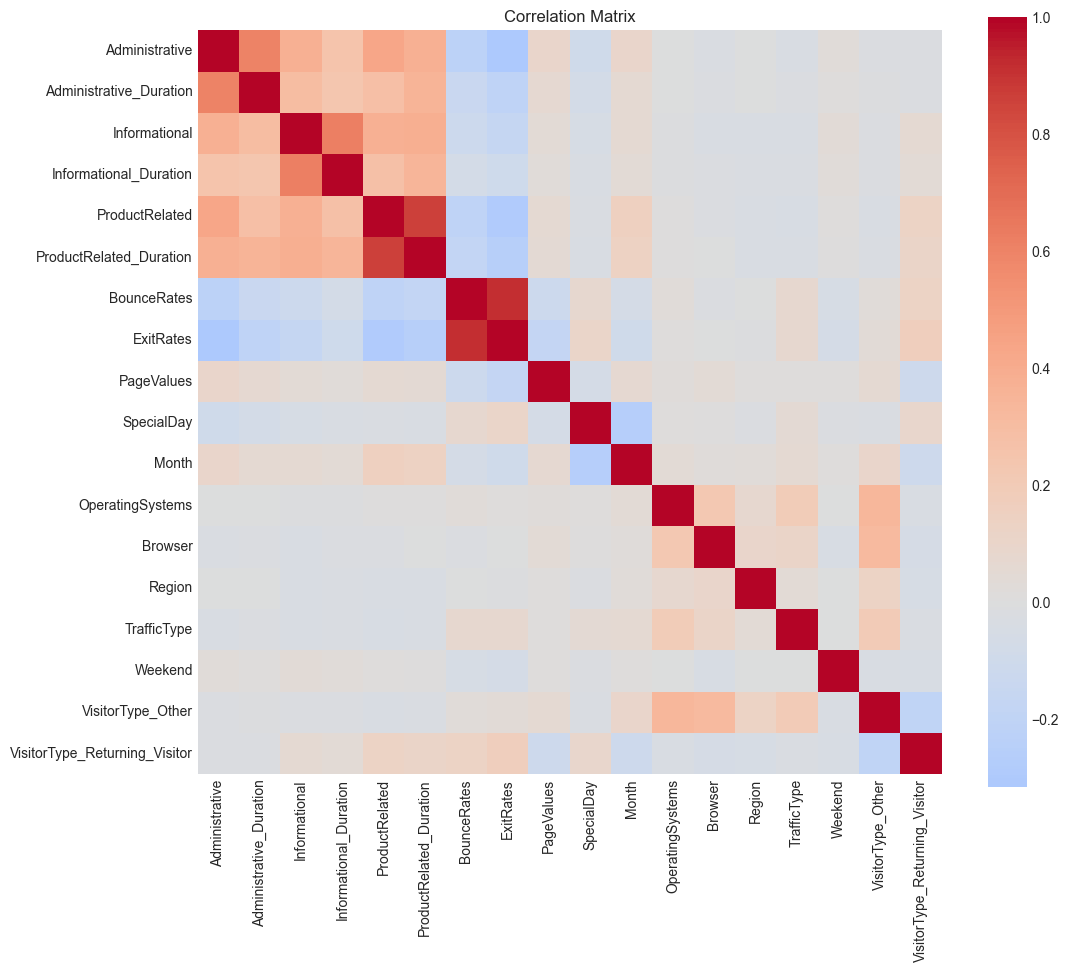


3. PCA 2D и 3D


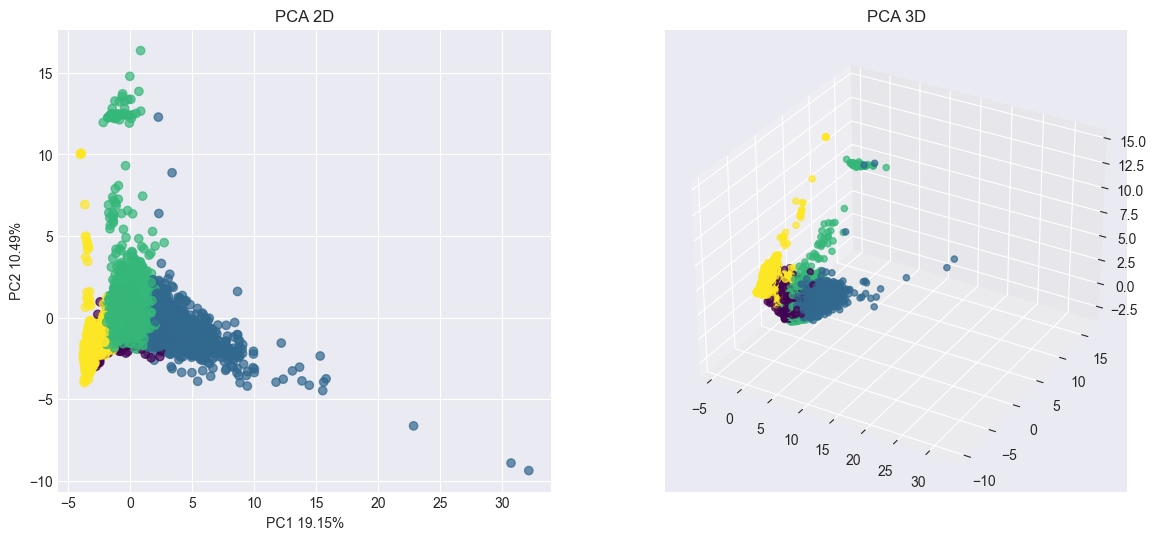


4. t-SNE


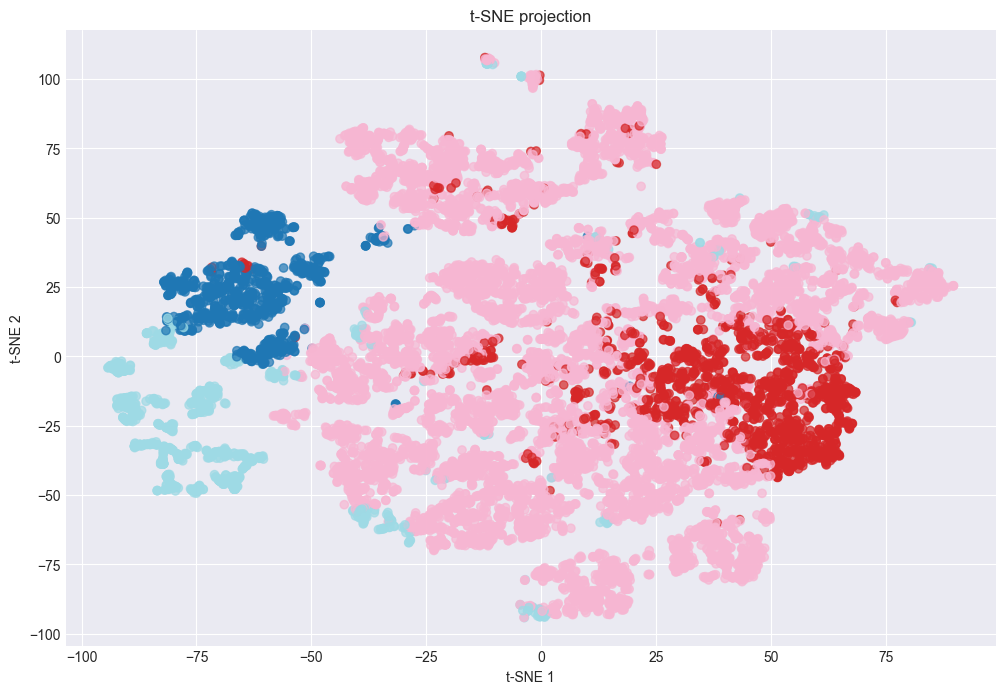


5. UMAP


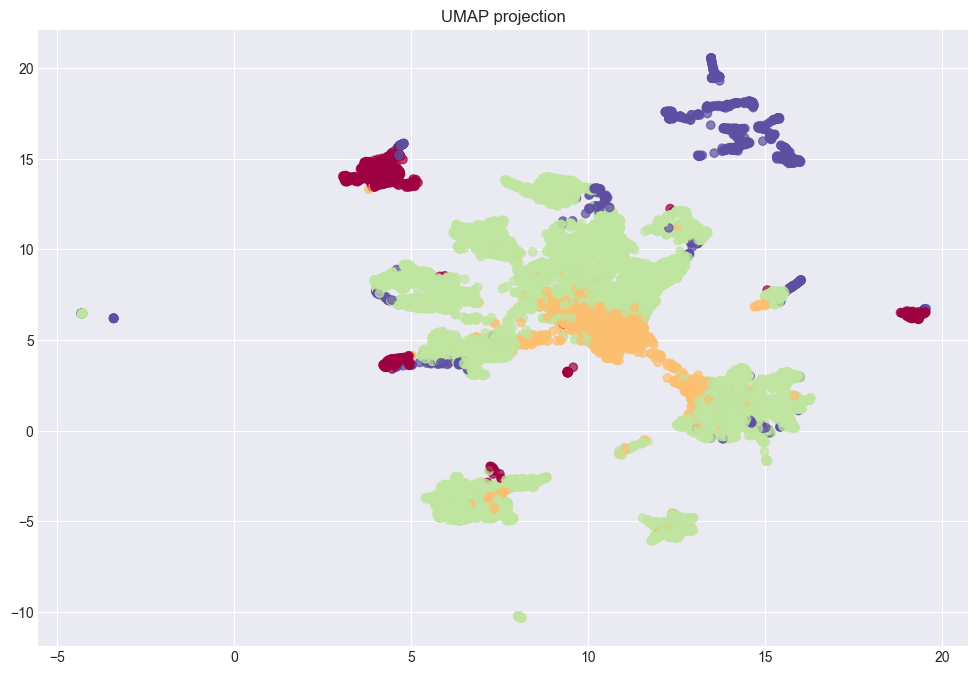


6. Parallel Coordinates


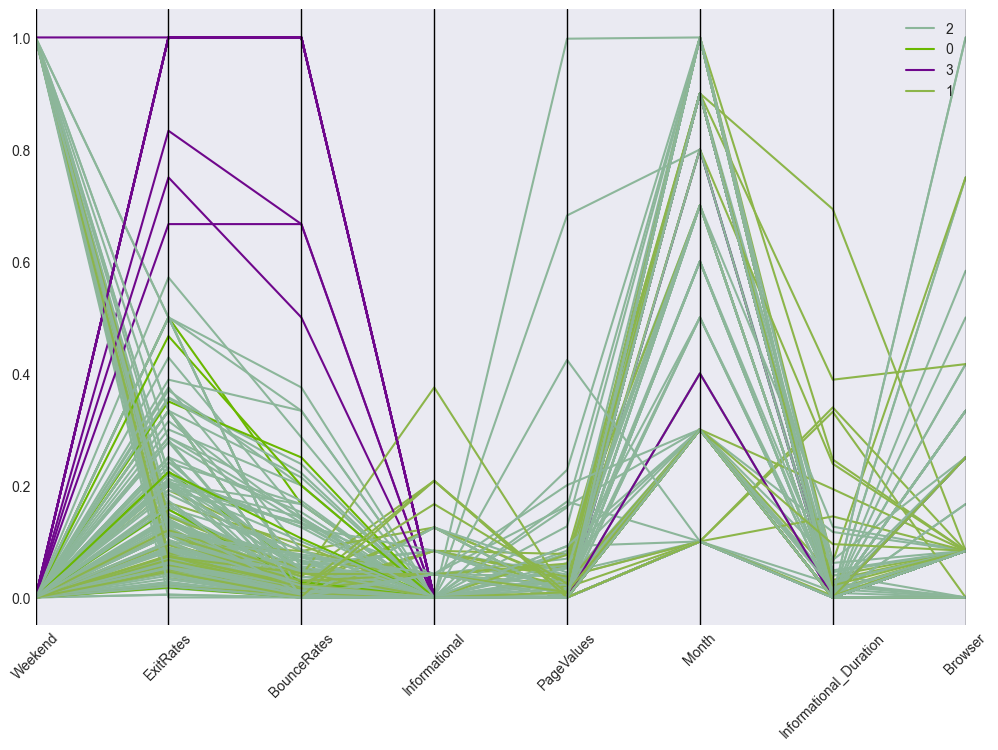


7. Radar chart


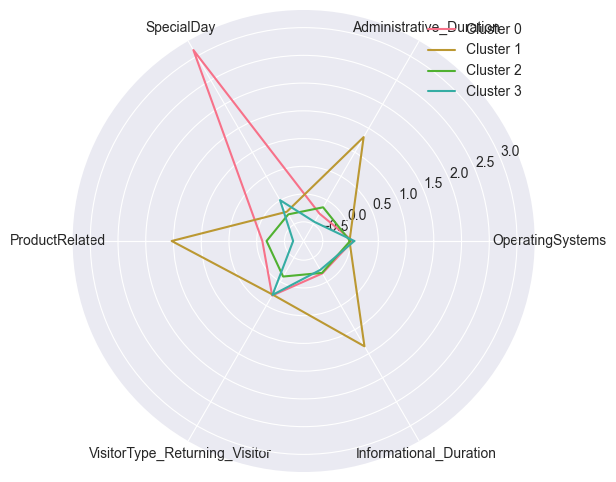


8. Interactive 3D plot
Интерактивный график сохранён в interactive_3d_plot.html

Визуализация завершена


In [4]:

print("Загрузка датасета online_shoppers_intention.csv")

df = pd.read_csv("online_shoppers_intention.csv")

print("\nПервые строки датасета:")
print(df.head())
print("\nРазмер датасета:", df.shape)
print("\nПреобразование категориальных признаков...")
month_map = {
    'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'June':6,
    'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12
}

df["Month"] = df["Month"].map(month_map)
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)
df = pd.get_dummies(df, columns=["VisitorType"], drop_first=True)

# Подготовка признаков
feature_names = df.drop(columns=["Revenue"]).columns.tolist()

X = df.drop(columns=["Revenue"]).values

# Нормализация данных

print("\nНормализация данных...")

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Кластеризация
print("\nКластеризация KMeans...")

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

y = kmeans.fit_predict(X)

# Базовая информация о данных

print(f"\nИнформация о данных:")
print(f"  Размер: {X.shape}")
print(f"  Количество кластеров: {len(np.unique(y))}")
print(f"  Количество признаков: {X.shape[1]}")
print(f"  Минимум: {X.min():.3f}, Максимум: {X.max():.3f}")
print(f"  Среднее: {X.mean():.3f}, Стандартное отклонение: {X.std():.3f}")

# Запуск визуализации

visualizer.run_full_visualization(X, y, feature_names)